In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GOOGLE_API_KEY")

In [2]:
!pip install -q -U langchain langgraph langchain-google-genai python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/136.9 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 9.9 MB/s eta 0:00:00


# 1. Importing Libraries

In [3]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

# 2.LLM

In [4]:
llm= ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=secret_value_0
)

# 3.Defining State

In [5]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str
    rate:float

# 4.Defining Node

## 4.1 Create Content

In [6]:
def create_outline(state:BlogState)->BlogState:
    title=state["title"]
    prompt=f"Generate a detailed outline on the topic {title}"
    outline=llm.invoke(prompt).content
    state["outline"]=outline
    return state
    

## 4.2 Create Blog

In [7]:
def create_blog(state:BlogState)->BlogState:
    title=state["title"]
    outline=state["outline"]
    prompt=f"Genetate a blog on the topic {title} on the following \n {outline}"
    content =llm.invoke(prompt).content
    state["content"]=content
    return state

## 4.3 Rate the Blog

In [8]:
def rate_blog(state:BlogState)->BlogState:
    title=state["title"]
    outline=state["outline"]
    content=state["content"]
    prompt =f"Give the rating out of 10 of the genereted blog {content} on the title {title} from the following content \n {content}"
    rate=llm.invoke(prompt).content
    state["rate"]=rate
    return state

# 5.Initialising State

In [9]:
graph=StateGraph(BlogState)

# 6.Adding Node

## 6.1 Adding create blog Node

In [10]:
graph.add_node("create_blog",create_blog)

## 6.2 Adding Create outline node

In [11]:
graph.add_node("create_outline",create_outline)

## 6.3 Adding rate the blog node

In [12]:
graph.add_node("rate_blog",rate_blog)

# 7.Adding Edges

In [13]:
graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog","rate_blog")
graph.add_edge("rate_blog",END)

# 8.Compilation

In [14]:
workflow=graph.compile()

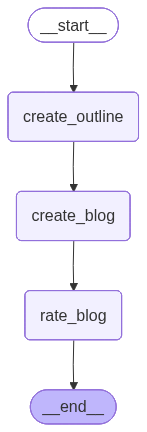

In [15]:
workflow

# 9.Initial State

In [16]:
initial_state={
    "title":"Rise of AI in the world"
}

# 10.Execution

In [17]:
result=workflow.invoke(initial_state)
print(result)

{'title': 'Rise of AI in the world', 'outline': 'This detailed outline covers the multi-faceted topic of the rise of AI, from its foundational concepts to its profound global impact and future implications.\n\n---\n\n## Detailed Outline: The Rise of AI in the World\n\n**I. Introduction to Artificial Intelligence**\n    A. Defining Artificial Intelligence (AI)\n        1. Broad Definition: Machines performing tasks typically requiring human intelligence\n        2. Narrow AI (ANI): AI designed and trained for a specific task (most current AI)\n        3. General AI (AGI): Hypothetical AI with human-level cognitive abilities across various tasks\n        4. Superintelligence: Hypothetical AI exceeding human intelligence\n    B. Core Concepts and Branches of AI\n        1. Machine Learning (ML): Algorithms learning from data without explicit programming\n            a. Supervised Learning\n            b. Unsupervised Learning\n            c. Reinforcement Learning\n        2. Deep Learnin

In [18]:
print(result["rate"])

## Rating: 9.0/10

Here's a breakdown of the rating:

**Strengths:**

1.  **Comprehensive & In-Depth:** This blog post is remarkably thorough. It covers an extensive range of topics related to AI, from its basic definitions and historical context to its current drivers, diverse applications, societal impact, significant challenges, ethical considerations, and future trends. It leaves almost no stone unturned.
2.  **Excellent Structure and Flow:** The blog is logically organized with clear, descriptive headings and subheadings. It progresses smoothly from an introduction to foundational concepts, historical evolution, current boom factors, applications, impact, challenges, future outlook, and a strong conclusion. This makes it easy to follow, even with its considerable length.
3.  **Clarity and Accessibility:** Despite discussing complex technical and philosophical concepts, the language remains clear, concise, and accessible to a broad audience. It avoids excessive jargon while still b